# 03 — Revenue Concentration, Risk & Statistical Testing

This notebook covers two things:

1. **Revenue Concentration & Risk** (Pareto, HHI, Gini, entropy) — how dependent is the
   business on a small number of opportunities / products / segments / geographies?
2. **Statistical Testing** — are the differences we saw in EDA (e.g. Enterprise vs
   Corporate deal value) actually statistically meaningful, or could they be noise?

Input: the opportunity-level table built in `02_eda.ipynb` (145 opportunities, deduplicated,
one row per Opportunity ID). We rebuild it here from raw so this notebook can run standalone,
using the exact same logic as 02_eda.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.options.display.float_format = "{:,.2f}".format
sns.set_style("whitegrid")

## Load data

Prefers the Phase 2 pipeline output (`data/processed/opportunities.parquet`) if it exists;
otherwise falls back to rebuilding the opportunity-level table from the raw Excel file the
same way `02_eda.ipynb` does, so this notebook doesn't hard-depend on Postgres being set up.

In [6]:
import os

PROCESSED_PATH = "../data/processed/opportunities.parquet"
RAW_PATH = "../data/raw/company_sales.xlsx"

if os.path.exists(PROCESSED_PATH):
    print("Loading from Phase 2 pipeline output (data/processed/opportunities.parquet)")
    opportunities = pd.read_parquet(PROCESSED_PATH)
    opportunities["close_date"] = pd.to_datetime(opportunities["close_date"])
else:
    print("Pipeline output not found, rebuilding opportunity table from raw Excel (same logic as 02_eda.ipynb)")
    sales_raw = pd.read_excel(RAW_PATH, sheet_name="Sales Data")
    people = pd.read_excel(RAW_PATH, sheet_name="People")
    sales_raw["Close Date"] = pd.to_datetime(sales_raw["Close Date"])

    sales = sales_raw.drop_duplicates().copy()

    opportunity_value = (
        sales.groupby("Opportunity ID")["Total Price"].sum().reset_index(name="opportunity_value")
    )
    opportunity_attributes = (
        sales.groupby("Opportunity ID")
        .agg({
            "Opp Owner User ID": "first",
            "Opp Owner Geo": "first",
            "Segment": "first",
            "Opportunity Type": "first",
            "Close Date": "first",
            "Product Line": lambda x: list(x),
        })
        .reset_index()
    )
    opportunity_attributes["product_family_count"] = sales.groupby("Opportunity ID").size().values

    opportunities = opportunity_attributes.merge(opportunity_value, on="Opportunity ID", how="left")
    opportunities = opportunities.merge(people, on="Opp Owner User ID", how="left")
    opportunities = opportunities.rename(columns={
        "Opportunity ID": "opportunity_id",
        "Opp Owner User ID": "opp_owner_user_id",
        "Opp Owner Geo": "opp_owner_geo",
        "Segment": "segment",
        "Opportunity Type": "opportunity_type",
        "Close Date": "close_date",
        "Name": "rep_name",
    })
    opportunities["rep_name"] = opportunities["rep_name"].fillna("Unknown Rep")
    opportunities["year"] = opportunities["close_date"].dt.year
    opportunities["quarter"] = opportunities["close_date"].dt.quarter
    opportunities["month"] = opportunities["close_date"].dt.month

    # Also need line-item level sales for product-market combination analysis
    sales_line_items = sales.rename(columns={
        "Opportunity ID": "opportunity_id",
        "Opp Owner Geo": "opp_owner_geo",
        "Segment": "segment",
        "Opportunity Type": "opportunity_type",
        "Product Line": "product_line",
        "Product Family": "product_family",
        "Total Price": "total_price",
    })

print("Opportunities shape:", opportunities.shape)
opportunities.head()

Pipeline output not found, rebuilding opportunity table from raw Excel (same logic as 02_eda.ipynb)
Opportunities shape: (145, 13)


,opportunity_id,opp_owner_user_id,opp_owner_geo,segment,opportunity_type,close_date,Product Line,product_family_count,opportunity_value,rep_name,year,quarter,month
0,0061Y00000QA0nIxRU,0054z00000AAVA1E0V,AMER,Enterprise,New Business,2019-09-06,"[Workforce, Workforce, Workforce]",3,"110,225.97",Alice Chen,2019,3,9
1,0061Y00000QA0nIxXH,0054z00000AAFA1E0p,AMER,Enterprise,Upsell,2019-04-12,"[Workforce, Workforce, Workforce]",3,"16,923.58",Bob Smith,2019,2,4
2,0061Y00000QA0nJ1PR,0051Y00000QAVBgScR,AMER,Corporate,New Business,2019-03-25,"[Workforce, Workforce, Workforce, Workforce]",4,"139,373.00",Charlie Day,2019,1,3
3,0061Y00000QA0nJ6NX,0054z00000AAJA0qTj,AMER,Corporate,Upsell,2019-03-22,[Workforce],1,"16,102.80",Diana Prince,2019,1,3
4,0061Y00000QA0nUpUC,0054z00000AAVA1E0V,AMER,Enterprise,Upsell,2019-05-06,"[Workforce, Workforce, Workforce]",3,"34,948.19",Alice Chen,2019,2,5


In [7]:
# Rebuild line-item table if we loaded from parquet (needed for product-market combos below)
if "sales_line_items" not in dir():
    stg_path = "../data/processed/stg_sales_clean.parquet"
    if os.path.exists(stg_path):
        sales_line_items = pd.read_parquet(stg_path)
    else:
        sales_raw = pd.read_excel(RAW_PATH, sheet_name="Sales Data")
        sales_line_items = sales_raw.drop_duplicates().rename(columns={
            "Opportunity ID": "opportunity_id",
            "Opp Owner Geo": "opp_owner_geo",
            "Segment": "segment",
            "Opportunity Type": "opportunity_type",
            "Product Line": "product_line",
            "Product Family": "product_family",
            "Total Price": "total_price",
        })

print("Line-item rows:", len(sales_line_items))

Line-item rows: 383


---
## Part 1 — Revenue Concentration & Risk (Phase 5)

The question here isn't "which category has the most value" (EDA already answered that).
It's: **how dependent is the company on a small slice of its opportunities / products /
markets?** A business where the top 5 deals are 60% of revenue is far riskier than one
generating the same total from 100 evenly-sized deals, even if both show "Workforce is the
biggest product line."

We use four complementary lenses:
- **Pareto analysis** — what % of value comes from the top X% of opportunities/combinations?
- **HHI (Herfindahl-Hirschman Index)** — a standard market-concentration index (sum of squared
  market shares). Common thresholds: <0.15 = unconcentrated, 0.15-0.25 = moderate, >0.25 = highly concentrated.
- **Gini coefficient** — inequality of value distribution, 0 = perfectly even, 1 = maximally unequal.
- **Entropy** — a diversification measure; higher entropy = more evenly spread across categories.

### 1.1 Pareto analysis — opportunity level

In [8]:
opp_sorted = opportunities.sort_values("opportunity_value", ascending=False).reset_index(drop=True)
opp_sorted["cum_value"] = opp_sorted["opportunity_value"].cumsum()
opp_sorted["cum_pct_value"] = opp_sorted["cum_value"] / opp_sorted["opportunity_value"].sum()
opp_sorted["cum_pct_opportunities"] = (opp_sorted.index + 1) / len(opp_sorted)

# Headline Pareto numbers
for pct in [0.05, 0.10, 0.20, 0.50]:
    n = max(1, int(round(pct * len(opp_sorted))))
    share = opp_sorted.iloc[:n]["opportunity_value"].sum() / opp_sorted["opportunity_value"].sum()
    print(f"Top {int(pct*100)}% of opportunities ({n} of {len(opp_sorted)}) = {share:.1%} of total value")

Top 5% of opportunities (7 of 145) = 28.4% of total value
Top 10% of opportunities (14 of 145) = 43.3% of total value
Top 20% of opportunities (29 of 145) = 66.3% of total value
Top 50% of opportunities (72 of 145) = 89.7% of total value


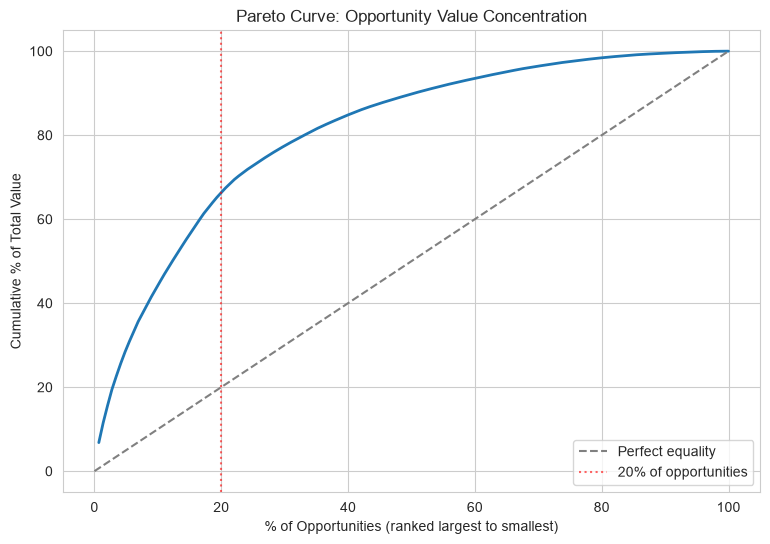

In [9]:
plt.figure(figsize=(9, 6))
plt.plot(opp_sorted["cum_pct_opportunities"] * 100, opp_sorted["cum_pct_value"] * 100, marker="", linewidth=2)
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Perfect equality")
plt.axvline(20, color="red", linestyle=":", alpha=0.6, label="20% of opportunities")
plt.xlabel("% of Opportunities (ranked largest to smallest)")
plt.ylabel("Cumulative % of Total Value")
plt.title("Pareto Curve: Opportunity Value Concentration")
plt.legend()
plt.show()

### 1.2 Pareto analysis — product-market combinations

Same idea, but at the `Product Family × Segment × Geography` grain, since that's the level the whole project is trying to reason about.

In [10]:
combo = (
    sales_line_items
    .groupby(["product_family", "segment", "opp_owner_geo"])["total_price"]
    .sum()
    .reset_index(name="total_value")
    .sort_values("total_value", ascending=False)
    .reset_index(drop=True)
)
combo["cum_pct_value"] = combo["total_value"].cumsum() / combo["total_value"].sum()
combo["combo_label"] = combo["product_family"] + " | " + combo["segment"] + " | " + combo["opp_owner_geo"]

print(f"Number of distinct Product Family x Segment x Geography combinations: {len(combo)}")
n_top5 = 5
top5_share = combo.iloc[:n_top5]["total_value"].sum() / combo["total_value"].sum()
print(f"Top {n_top5} combinations = {top5_share:.1%} of total value")

combo.head(10)[["combo_label", "total_value", "cum_pct_value"]]

Number of distinct Product Family x Segment x Geography combinations: 30
Top 5 combinations = 48.5% of total value


,combo_label,total_value,cum_pct_value
0,CIAM - A | Enterprise | EMEA,"907,271.46",0.13
1,Workforce - C | Enterprise | AMER,"694,943.16",0.23
2,Workforce - B | Enterprise | EMEA,"629,937.47",0.32
3,Workforce - B | Enterprise | AMER,"616,415.95",0.40
4,Workforce - C | Enterprise | EMEA,"580,393.51",0.48
5,CIAM - A | Enterprise | AMER,"467,453.50",0.55
6,Workforce - A | Enterprise | AMER,"376,483.73",0.60
7,Workforce - B | Corporate | EMEA,"316,595.25",0.65
8,Workforce - C | Corporate | EMEA,"297,009.76",0.69
9,Workforce - A | Enterprise | EMEA,"292,844.50",0.73


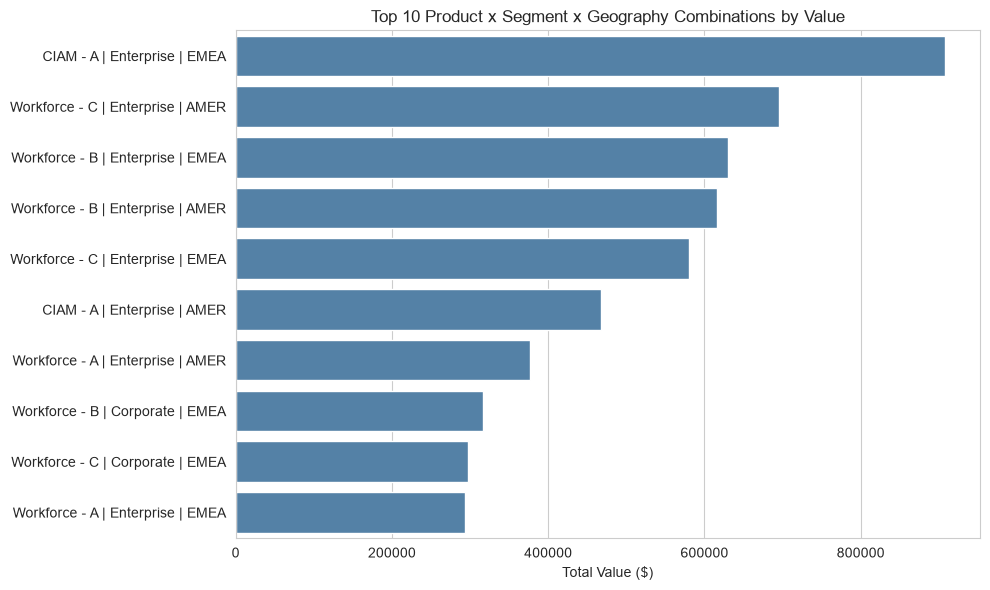

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=combo.head(10), y="combo_label", x="total_value", color="steelblue")
plt.title("Top 10 Product x Segment x Geography Combinations by Value")
plt.xlabel("Total Value ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 1.3 HHI (Herfindahl-Hirschman Index)

HHI = sum of squared market shares (shares as fractions 0-1, so HHI ranges 0 to 1). We compute it for each dimension and for the full product-market combination.

In [12]:
def hhi(values):
    shares = values / values.sum()
    return (shares ** 2).sum()

def hhi_label(h):
    if h < 0.15:
        return "Unconcentrated"
    elif h < 0.25:
        return "Moderately concentrated"
    else:
        return "Highly concentrated"

dimensions = {
    "Product Family": sales_line_items.groupby("product_family")["total_price"].sum(),
    "Segment": opportunities.groupby("segment")["opportunity_value"].sum(),
    "Geography": opportunities.groupby("opp_owner_geo")["opportunity_value"].sum(),
    "Opportunity Type": opportunities.groupby("opportunity_type")["opportunity_value"].sum(),
    "Product x Segment x Geography combo": combo.set_index("combo_label")["total_value"],
}

hhi_results = []
for name, series in dimensions.items():
    h = hhi(series.values)
    hhi_results.append({"Dimension": name, "HHI": h, "Interpretation": hhi_label(h), "N categories": len(series)})

hhi_df = pd.DataFrame(hhi_results)
hhi_df

,Dimension,HHI,Interpretation,N categories
0,Product Family,0.23,Moderately concentrated,6
1,Segment,0.62,Highly concentrated,2
2,Geography,0.40,Highly concentrated,3
3,Opportunity Type,0.55,Highly concentrated,2
4,Product x Segment x Geography combo,0.07,Unconcentrated,30


/var/folders/f_/1mm1mz0x0rdg1ysp2gw5927r0000gn/T/ipykernel_43260/1121452558.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hhi_df, x="HHI", y="Dimension", palette=colors)


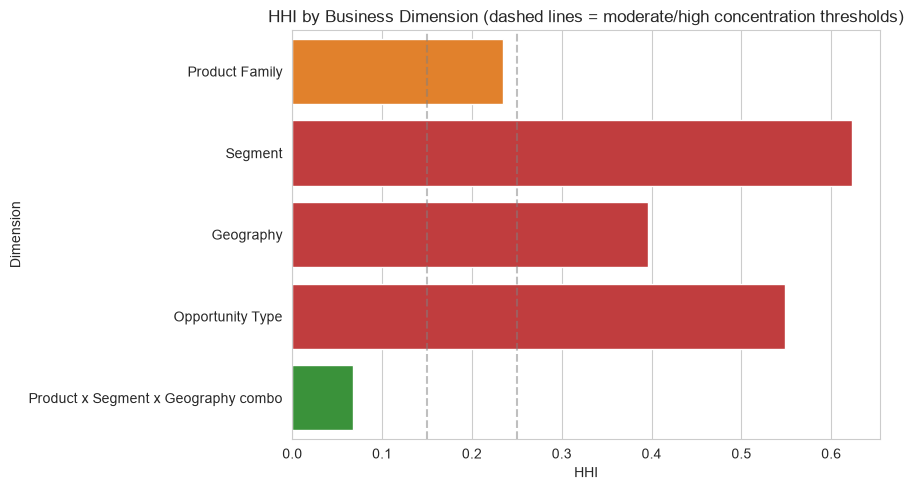

In [13]:
plt.figure(figsize=(9, 5))
colors = ["#d62728" if h > 0.25 else "#ff7f0e" if h > 0.15 else "#2ca02c" for h in hhi_df["HHI"]]
sns.barplot(data=hhi_df, x="HHI", y="Dimension", palette=colors)
plt.axvline(0.15, color="gray", linestyle="--", alpha=0.5)
plt.axvline(0.25, color="gray", linestyle="--", alpha=0.5)
plt.title("HHI by Business Dimension (dashed lines = moderate/high concentration thresholds)")
plt.tight_layout()
plt.show()

### 1.4 Gini coefficient

Applied at the opportunity level (inequality of individual deal sizes) and at the product-market combo level.

In [14]:
def gini(values):
    values = np.sort(np.asarray(values, dtype=float))
    n = len(values)
    cum_values = np.cumsum(values)
    return (n + 1 - 2 * (cum_values.sum() / cum_values[-1])) / n

gini_opportunity = gini(opportunities["opportunity_value"].values)
gini_combo = gini(combo["total_value"].values)

print(f"Gini coefficient, opportunity-level deal sizes: {gini_opportunity:.3f}")
print(f"Gini coefficient, product-market combination values: {gini_combo:.3f}")
print("(0 = perfectly even distribution, 1 = maximal inequality / one entity has everything)")

Gini coefficient, opportunity-level deal sizes: 0.615
Gini coefficient, product-market combination values: 0.530
(0 = perfectly even distribution, 1 = maximal inequality / one entity has everything)


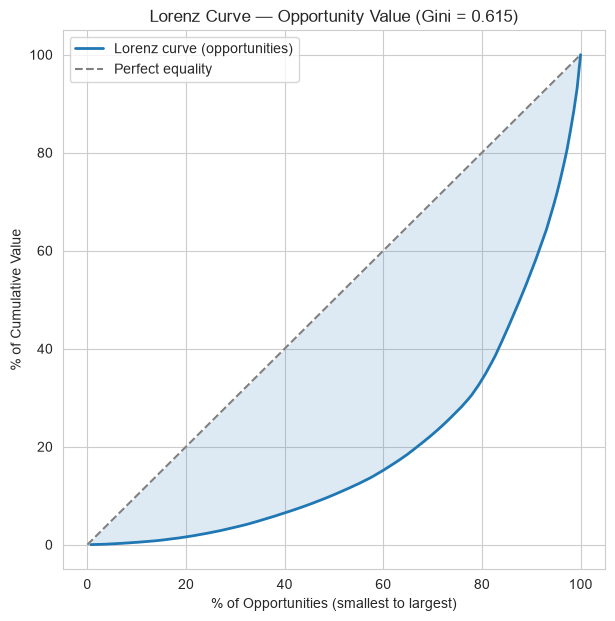

In [15]:
# Lorenz curve for opportunity-level values
values_sorted = np.sort(opportunities["opportunity_value"].values)
cum_share = np.cumsum(values_sorted) / values_sorted.sum()
pop_share = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

plt.figure(figsize=(7, 7))
plt.plot(pop_share * 100, cum_share * 100, linewidth=2, label="Lorenz curve (opportunities)")
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Perfect equality")
plt.fill_between(pop_share * 100, cum_share * 100, pop_share * 100, alpha=0.15)
plt.xlabel("% of Opportunities (smallest to largest)")
plt.ylabel("% of Cumulative Value")
plt.title(f"Lorenz Curve — Opportunity Value (Gini = {gini_opportunity:.3f})")
plt.legend()
plt.show()

### 1.5 Entropy (diversification)

Shannon entropy of the share distribution, normalized to 0-1 (1 = maximally diversified given the number of categories, 0 = all value in one category).

In [16]:
def normalized_entropy(values):
    shares = values / values.sum()
    shares = shares[shares > 0]
    h = -(shares * np.log(shares)).sum()
    h_max = np.log(len(shares))
    return h / h_max if h_max > 0 else 0.0

entropy_results = []
for name, series in dimensions.items():
    entropy_results.append({"Dimension": name, "Normalized Entropy": normalized_entropy(series.values)})

entropy_df = pd.DataFrame(entropy_results)
entropy_df

,Dimension,Normalized Entropy
0,Product Family,0.85
1,Segment,0.81
2,Geography,0.91
3,Opportunity Type,0.93
4,Product x Segment x Geography combo,0.86


### 1.6 Concentration over time

Is the business becoming more or less concentrated year over year? Tracked using yearly HHI at the product-family level. 2022 has only 1 opportunity, so it's kept for completeness but shouldn't be over-interpreted.

In [17]:
yearly_hhi = []
for yr, group in sales_line_items.merge(
        opportunities[["opportunity_id", "year"]], on="opportunity_id", how="left"
    ).groupby("year"):
    yr_values = group.groupby("product_family")["total_price"].sum()
    yearly_hhi.append({
        "Year": yr,
        "HHI (Product Family)": hhi(yr_values.values),
        "N Opportunities": group["opportunity_id"].nunique(),
    })

yearly_hhi_df = pd.DataFrame(yearly_hhi).sort_values("Year")
yearly_hhi_df

,Year,HHI (Product Family),N Opportunities
0,2019,0.30,37
1,2020,0.23,91
2,2021,0.29,16
3,2022,1.00,1


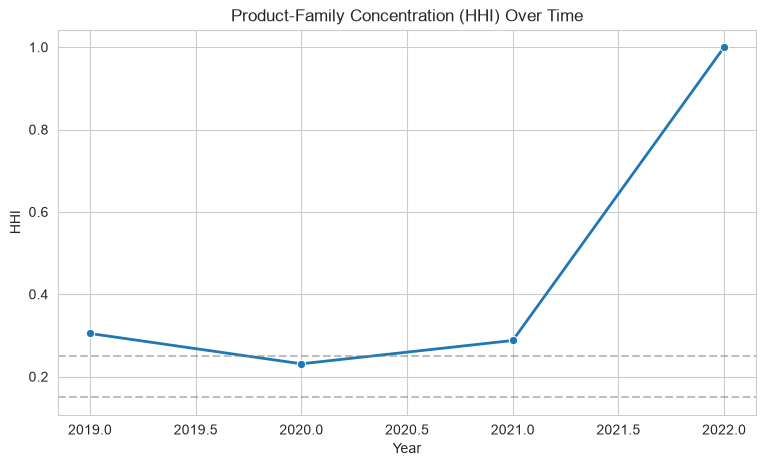

Note: 2021-2022 have very few opportunities (16 and 1 respectively), so HHI swings
in those years should be read as low-sample-size noise, not a reliable trend.


In [18]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=yearly_hhi_df, x="Year", y="HHI (Product Family)", marker="o", linewidth=2)
plt.axhline(0.15, color="gray", linestyle="--", alpha=0.5)
plt.axhline(0.25, color="gray", linestyle="--", alpha=0.5)
plt.title("Product-Family Concentration (HHI) Over Time")
plt.ylabel("HHI")
plt.show()

print("Note: 2021-2022 have very few opportunities (16 and 1 respectively), so HHI swings")
print("in those years should be read as low-sample-size noise, not a reliable trend.")

### 1.7 Concentration summary

Fill this in once you've looked at the numbers above — that's the point of the project (findings
should come from the data, not be predetermined). Prompts to answer here:

- Which single dimension has the highest HHI, and does that match the "core revenue engine" you'd expect from EDA?
- Does the Product x Segment x Geography combo-level HHI show a much higher concentration than any single dimension alone? (This is the key finding Phase 5 is designed to surface — value can look diversified one dimension at a time but be highly concentrated in specific combinations.)
- Is the Gini coefficient consistent with the HHI story, or do they disagree (e.g. many small deals but one dominant category)?
- Is concentration trending up or down over 2019-2020 (the two years with enough volume to trust)?

---
## Part 2 — Statistical Testing (Phase 6)

EDA showed apparent differences (e.g. Enterprise's median deal ~$62.8K vs Corporate's ~$15.3K).
Here we test whether these differences are statistically meaningful, using the right test for
each distribution shape, plus effect sizes and confidence intervals — not just p-values.

**Workflow per test:**
1. Check distribution shape / normality (deal values are typically right-skewed, so we check before assuming a t-test is appropriate)
2. Run the appropriate parametric test AND its non-parametric counterpart
3. Report an effect size (not just significance)
4. State the conclusion in plain business language

### 2.1 Check distribution shape of opportunity value

Deal values are almost always right-skewed in B2B sales data — confirming this determines whether Welch's t-test or Mann-Whitney U is more appropriate.

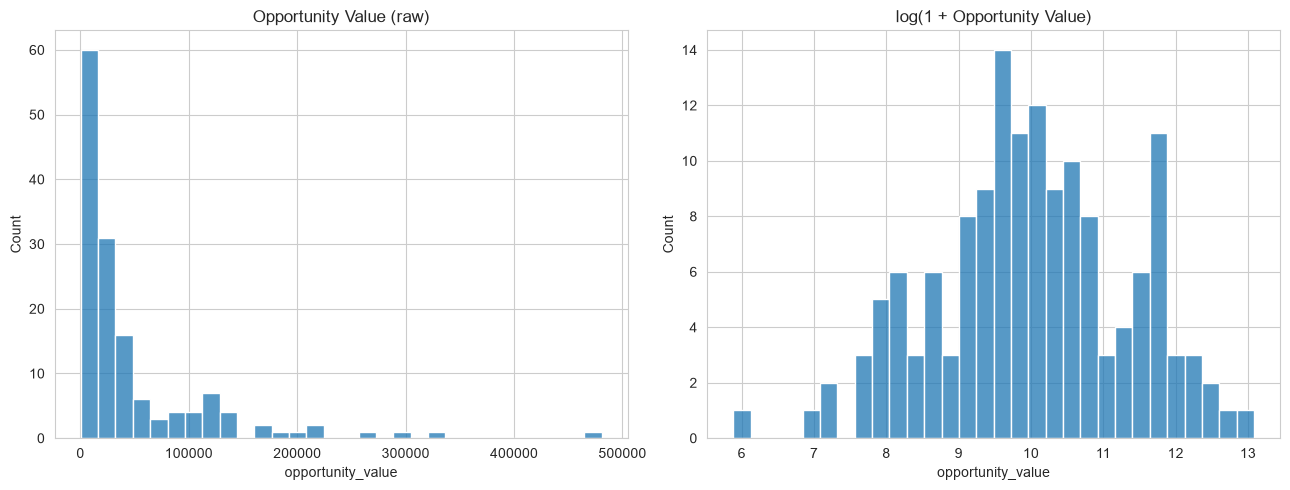

Skewness of raw opportunity_value: 3.02 (0 = symmetric; well above 1 = strongly right-skewed)
Shapiro-Wilk normality test: stat=0.647, p=0.0000
p < 0.05 -> reject normality -> favor non-parametric tests (Mann-Whitney/Kruskal-Wallis)
           as primary evidence, with Welch's t-test reported alongside for comparison.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(opportunities["opportunity_value"], bins=30, ax=axes[0])
axes[0].set_title("Opportunity Value (raw)")

sns.histplot(np.log1p(opportunities["opportunity_value"]), bins=30, ax=axes[1])
axes[1].set_title("log(1 + Opportunity Value)")
plt.tight_layout()
plt.show()

skew = opportunities["opportunity_value"].skew()
print(f"Skewness of raw opportunity_value: {skew:.2f} (0 = symmetric; well above 1 = strongly right-skewed)")

shapiro_stat, shapiro_p = stats.shapiro(opportunities["opportunity_value"])
print(f"Shapiro-Wilk normality test: stat={shapiro_stat:.3f}, p={shapiro_p:.4f}")
print("p < 0.05 -> reject normality -> favor non-parametric tests (Mann-Whitney/Kruskal-Wallis)")
print("           as primary evidence, with Welch's t-test reported alongside for comparison.")

### 2.2 Enterprise vs Corporate deal value

**H0:** Enterprise and Corporate opportunities come from the same deal-value distribution.
**H1:** They differ.

In [20]:
enterprise_vals = opportunities.loc[opportunities["segment"] == "Enterprise", "opportunity_value"]
corporate_vals = opportunities.loc[opportunities["segment"] == "Corporate", "opportunity_value"]

print(f"Enterprise: n={len(enterprise_vals)}, mean=${enterprise_vals.mean():,.0f}, median=${enterprise_vals.median():,.0f}")
print(f"Corporate:  n={len(corporate_vals)}, mean=${corporate_vals.mean():,.0f}, median=${corporate_vals.median():,.0f}")

# Welch's t-test (does not assume equal variances)
t_stat, t_p = stats.ttest_ind(enterprise_vals, corporate_vals, equal_var=False)
print(f"\nWelch's t-test: t={t_stat:.3f}, p={t_p:.5f}")

# Mann-Whitney U (non-parametric, robust to skew)
u_stat, u_p = stats.mannwhitneyu(enterprise_vals, corporate_vals, alternative="two-sided")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={u_p:.5f}")

# Effect size: Cohen's d (for reference alongside t-test)
pooled_std = np.sqrt(((len(enterprise_vals)-1)*enterprise_vals.std()**2 + (len(corporate_vals)-1)*corporate_vals.std()**2) /
                      (len(enterprise_vals) + len(corporate_vals) - 2))
cohens_d = (enterprise_vals.mean() - corporate_vals.mean()) / pooled_std
print(f"\nCohen's d: {cohens_d:.3f} (0.2=small, 0.5=medium, 0.8=large)")

# Effect size: rank-biserial correlation (for Mann-Whitney)
n1, n2 = len(enterprise_vals), len(corporate_vals)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

# 95% CI for the difference in means via bootstrap
rng = np.random.default_rng(42)
diffs = []
for _ in range(5000):
    e_sample = rng.choice(enterprise_vals, size=n1, replace=True)
    c_sample = rng.choice(corporate_vals, size=n2, replace=True)
    diffs.append(e_sample.mean() - c_sample.mean())
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
print(f"\nBootstrap 95% CI for (Enterprise mean - Corporate mean): (${ci_low:,.0f}, ${ci_high:,.0f})")

Enterprise: n=58, mean=$91,214, median=$62,756
Corporate:  n=87, mean=$20,475, median=$15,336

Welch's t-test: t=5.690, p=0.00000
Mann-Whitney U: U=4049.0, p=0.00000

Cohen's d: 1.154 (0.2=small, 0.5=medium, 0.8=large)
Rank-biserial correlation: -0.605

Bootstrap 95% CI for (Enterprise mean - Corporate mean): ($48,777, $95,713)


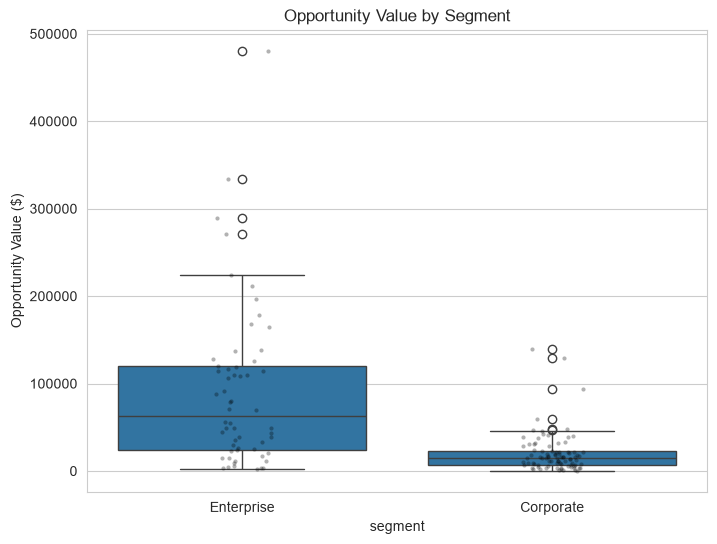

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=opportunities, x="segment", y="opportunity_value")
sns.stripplot(data=opportunities, x="segment", y="opportunity_value", color="black", alpha=0.3, size=3)
plt.title("Opportunity Value by Segment")
plt.ylabel("Opportunity Value ($)")
plt.show()

**Conclusion:** *(fill in once you've run this — expect a low p-value given the EDA gap, but state the effect size in plain terms, e.g. "Enterprise deals are on average X times larger than Corporate deals, and this is very unlikely to be due to chance.")*

### 2.3 Upsell vs New Business deal value

**H0:** Upsell and New Business opportunities have similar deal-value distributions.
**H1:** They differ.

In [22]:
upsell_vals = opportunities.loc[opportunities["opportunity_type"] == "Upsell", "opportunity_value"]
new_biz_vals = opportunities.loc[opportunities["opportunity_type"] == "New Business", "opportunity_value"]

print(f"Upsell:       n={len(upsell_vals)}, mean=${upsell_vals.mean():,.0f}, median=${upsell_vals.median():,.0f}")
print(f"New Business: n={len(new_biz_vals)}, mean=${new_biz_vals.mean():,.0f}, median=${new_biz_vals.median():,.0f}")

t_stat, t_p = stats.ttest_ind(upsell_vals, new_biz_vals, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(upsell_vals, new_biz_vals, alternative="two-sided")

print(f"\nWelch's t-test: t={t_stat:.3f}, p={t_p:.5f}")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={u_p:.5f}")

n1, n2 = len(upsell_vals), len(new_biz_vals)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

Upsell:       n=102, mean=$45,451, median=$18,638
New Business: n=43, mean=$56,645, median=$31,202

Welch's t-test: t=-0.911, p=0.36464
Mann-Whitney U: U=1807.0, p=0.09516
Rank-biserial correlation: 0.176


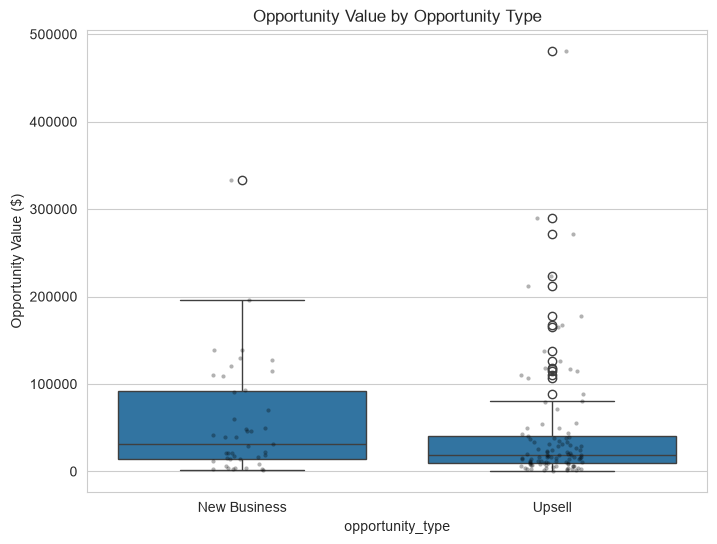

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=opportunities, x="opportunity_type", y="opportunity_value")
sns.stripplot(data=opportunities, x="opportunity_type", y="opportunity_value", color="black", alpha=0.3, size=3)
plt.title("Opportunity Value by Opportunity Type")
plt.ylabel("Opportunity Value ($)")
plt.show()

**Conclusion:** *(fill in — note that Upsell had far more opportunities but a lower median in EDA; check whether that difference is statistically significant or could be sampling noise given n=102 vs n=43)*

### 2.4 Geography differences (3 groups: AMER, EMEA, APAC)

**H0:** All three geographies have the same deal-value distribution.
**H1:** At least one differs.

With 3+ groups we need ANOVA (parametric) or Kruskal-Wallis (non-parametric) instead of a two-sample test.

In [24]:
geo_groups = [group["opportunity_value"].values for _, group in opportunities.groupby("opp_owner_geo")]
geo_names = opportunities["opp_owner_geo"].unique()

f_stat, f_p = stats.f_oneway(*geo_groups)
h_stat, h_p = stats.kruskal(*geo_groups)

print(f"One-way ANOVA:    F={f_stat:.3f}, p={f_p:.5f}")
print(f"Kruskal-Wallis H: H={h_stat:.3f}, p={h_p:.5f}")

# Effect size: eta-squared for ANOVA
grand_mean = opportunities["opportunity_value"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in geo_groups)
ss_total = ((opportunities["opportunity_value"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total
print(f"Eta-squared: {eta_sq:.3f} (0.01=small, 0.06=medium, 0.14=large)")

One-way ANOVA:    F=0.584, p=0.55908
Kruskal-Wallis H: H=4.381, p=0.11185
Eta-squared: 0.008 (0.01=small, 0.06=medium, 0.14=large)


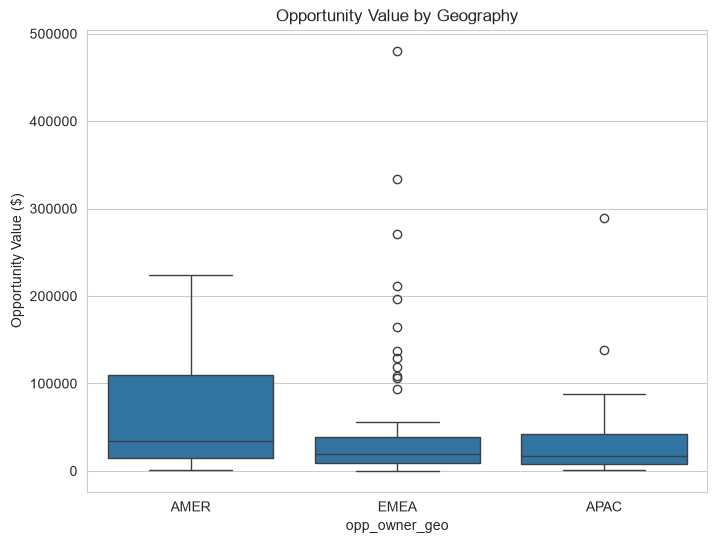

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=opportunities, x="opp_owner_geo", y="opportunity_value")
plt.title("Opportunity Value by Geography")
plt.ylabel("Opportunity Value ($)")
plt.show()

In [26]:
# If the omnibus test is significant, run pairwise Mann-Whitney with Bonferroni correction
from itertools import combinations

geos = opportunities["opp_owner_geo"].unique()
pairs = list(combinations(geos, 2))
alpha_corrected = 0.05 / len(pairs)

print(f"Bonferroni-corrected alpha for {len(pairs)} pairwise comparisons: {alpha_corrected:.4f}\n")

for g1, g2 in pairs:
    v1 = opportunities.loc[opportunities["opp_owner_geo"] == g1, "opportunity_value"]
    v2 = opportunities.loc[opportunities["opp_owner_geo"] == g2, "opportunity_value"]
    u, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
    sig = "SIGNIFICANT" if p < alpha_corrected else "not significant"
    print(f"{g1} vs {g2}: U={u:.1f}, p={p:.4f} -> {sig} (after Bonferroni correction)")

Bonferroni-corrected alpha for 3 pairwise comparisons: 0.0167

AMER vs EMEA: U=1952.0, p=0.0718 -> not significant (after Bonferroni correction)
AMER vs APAC: U=744.0, p=0.0766 -> not significant (after Bonferroni correction)
EMEA vs APAC: U=1064.5, p=0.6179 -> not significant (after Bonferroni correction)


**Conclusion:** *(fill in — with only 3 groups and moderate n, watch out for low power on pairwise comparisons even if the omnibus test is significant)*

### 2.5 Product Line differences (Workforce vs CIAM)

**H0:** Workforce and CIAM opportunities have similar deal-value distributions.
**H1:** They differ.

Note: Product Line lives at the line-item grain, not the opportunity grain (an opportunity can contain both). We test this on line-item `total_price`, matching how EDA reported it.

In [27]:
workforce_vals = sales_line_items.loc[sales_line_items["product_line"] == "Workforce", "total_price"]
ciam_vals = sales_line_items.loc[sales_line_items["product_line"] == "CIAM", "total_price"]

print(f"Workforce: n={len(workforce_vals)}, mean=${workforce_vals.mean():,.0f}, median=${workforce_vals.median():,.0f}")
print(f"CIAM:      n={len(ciam_vals)}, mean=${ciam_vals.mean():,.0f}, median=${ciam_vals.median():,.0f}")

t_stat, t_p = stats.ttest_ind(workforce_vals, ciam_vals, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(workforce_vals, ciam_vals, alternative="two-sided")

print(f"\nWelch's t-test: t={t_stat:.3f}, p={t_p:.5f}")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={u_p:.5f}")

n1, n2 = len(workforce_vals), len(ciam_vals)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

Workforce: n=346, mean=$15,329, median=$6,041
CIAM:      n=37, mean=$47,778, median=$23,174

Welch's t-test: t=-4.184, p=0.00016
Mann-Whitney U: U=2465.0, p=0.00000
Rank-biserial correlation: 0.615


**Conclusion:** *(fill in)*

### 2.6 Are product differences consistent across segments? (interaction check)

A quick look at whether the Workforce-vs-CIAM gap holds up the same way inside Enterprise as it
does inside Corporate — if the gap flips or disappears in one segment, that's a sign the "product"
effect is really being driven by segment mix, which is exactly the confound the full project doc
calls out. This gets modeled properly with interaction terms in `04_modeling.ipynb`; this is just
a first look.

In [28]:
interaction_check = (
    sales_line_items
    .groupby(["product_line", "segment"])["total_price"]
    .agg(["count", "mean", "median"])
    .round(0)
)
interaction_check

count      mean    median
product_line segment                              
CIAM         Corporate      13 19,564.00 12,456.00
             Enterprise     24 63,061.00 51,958.00
Workforce    Corporate     210  7,271.00  4,463.00
             Enterprise    136 27,772.00 13,235.00

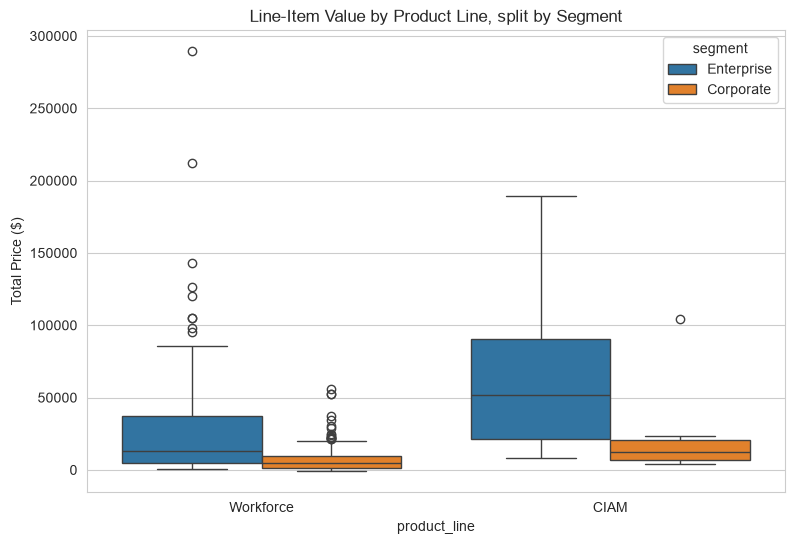

If the gap between Workforce and CIAM looks very different across the two segment panels,
that's evidence the raw product-line comparison in 2.5 is confounded by segment mix --
this is exactly what the Product x Segment interaction term in 04_modeling.ipynb will test formally.


In [29]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=sales_line_items, x="product_line", y="total_price", hue="segment")
plt.title("Line-Item Value by Product Line, split by Segment")
plt.ylabel("Total Price ($)")
plt.show()

print("If the gap between Workforce and CIAM looks very different across the two segment panels,")
print("that's evidence the raw product-line comparison in 2.5 is confounded by segment mix --")
print("this is exactly what the Product x Segment interaction term in 04_modeling.ipynb will test formally.")

---
## Summary

Concentration: Top 5% of opportunities (7 deals) = 28% of total value; top 20% = 66%. Classic Pareto pattern. HHI tells an important story: individual dimensions look only moderately concentrated (Product Family 0.23, Geography 0.40) but Segment (0.62) and Opportunity Type (0.55) are highly concentrated — while the 30-way Product×Segment×Geography combo HHI is only 0.07 ("unconcentrated"). That's the opposite of what the project doc predicted — value is actually more spread out at the granular combo level than within any single dimension, because no combo dominates (top combo, CIAM-A|Enterprise|EMEA, is only 13% of value). Gini = 0.615 at the opportunity level (fairly unequal deal sizes) and 0.53 across combos. Entropy is high everywhere (0.81–0.93) — consistent with the low combo-level HHI.
Statistical tests:
Enterprise vs Corporate: highly significant (p<0.00001, Cohen's d=1.15 — a large effect). Enterprise deals average ~4.5x Corporate's.
Upsell vs New Business: not significant (t-test p=0.36, Mann-Whitney p=0.095) — the EDA gap doesn't hold up statistically.
Geography (AMER/EMEA/APAC): not significant (ANOVA p=0.56, Kruskal-Wallis p=0.11, eta²=0.008 — negligible effect).
Workforce vs CIAM: highly significant (p<0.001, but note CIAM's mean is pulled up by Enterprise mix — see below).
Interaction check: CIAM/Enterprise mean ($63K) vastly exceeds CIAM/Corporate ($19.6K), and same pattern for Workforce — confirming the product-line gap is entangled with segment, exactly what 04's interaction terms were built to test.